In [1]:
import torch
from pathlib import Path
import preprocess_data as ppd
from process_session import session as ss
import process_probe as pp
import numpy as np
from preprocess_data import *
from torch.utils.data import DataLoader, TensorDataset
import models as models
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# Session obj contains stimulus, channel, and unit information
session_id = 1044385384
session_obj = ss(session_id)

In [16]:
# Training hyperparameters
input_size = len(session_obj.units)
hidden_size = 50 # 
num_layers = 1
seqlength = 750
num_epochs = 15 # 

In [26]:
# Spikes obj contains Spike matrix
bin_size=0.004
spikes_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[1])
spikes_obj.truncate(seqlength)
spikes_obj.convolve_with_gaussian()
spikes_obj.zscore()

100%|██████████| 741/741 [01:11<00:00, 10.34it/s]


In [28]:
# Probe obj contains LFP data
# Getting LFP  for active trials
output_dir = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data'
lfp_obj = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.active_times[0],
                              session_obj.active_times[1], output_dir) 
lfp_obj.filter_lfp()
lfp_obj.downsample_lfp(5) # Downsample by 5
lfp_obj.truncate(seqlength) # Downsample by 5
lfp_obj.align_lfp(spikes_obj.spkMat.shape[0])

100%|██████████| 8/8 [03:38<00:00, 27.26s/it]


In [45]:
# get spontaneous data
spikes_obj_spont = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj_spont.getSpkMat(session_obj.spontaneous_times[0], session_obj.spontaneous_times[1])
spikes_obj_spont.truncate(seqlength)
spikes_obj_spont.convolve_with_gaussian()
spikes_obj_spont.zscore()

lfp_obj_spont = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.spontaneous_times[0],
                              session_obj.spontaneous_times[1], output_dir) 
lfp_obj_spont.filter_lfp()
lfp_obj_spont.downsample_lfp(5) # Downsample by 5
lfp_obj_spont.truncate(seqlength) # Downsample by 5
lfp_obj_spont.align_lfp(spikes_obj_spont.spkMat.shape[0])

  0%|          | 0/741 [00:00<?, ?it/s]

100%|██████████| 741/741 [00:05<00:00, 138.20it/s]


In [30]:
chani = 5 # deep layer
bandi = 0 # broadband

X_train, X_test, y_train, y_test = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,chani,bandi] , seqlength, test_size=0.2, random_state=42)

# Convert to PyTorch tensors and move to GPU
X_train = torch.from_numpy(X_train).float().to(device)
X_test = torch.from_numpy(X_test).float().to(device)
y_train = torch.from_numpy(y_train).float().to(device)
y_test = torch.from_numpy(y_test).float().to(device)

# Create DataLoader for batching
train_dataset = TensorDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [13]:
# linear regression model 
linear_model = models.LinearRegressionModel(input_size)
ln_train_loss, ln_test_loss = linear_model.train(train_dataloader,
                                               test_dataloader, numepochs=1)

print(f'Linear regression train loss: {ln_train_loss[-1]:.4f}')
print(f'Linear regression test loss: {ln_test_loss[-1]:.4f}')

Linear regression train loss: 0.3439
Linear regression test loss: 0.5614


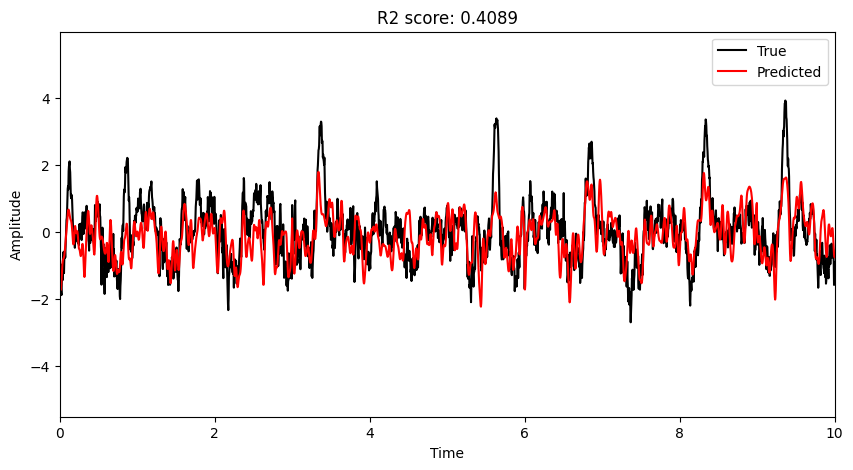

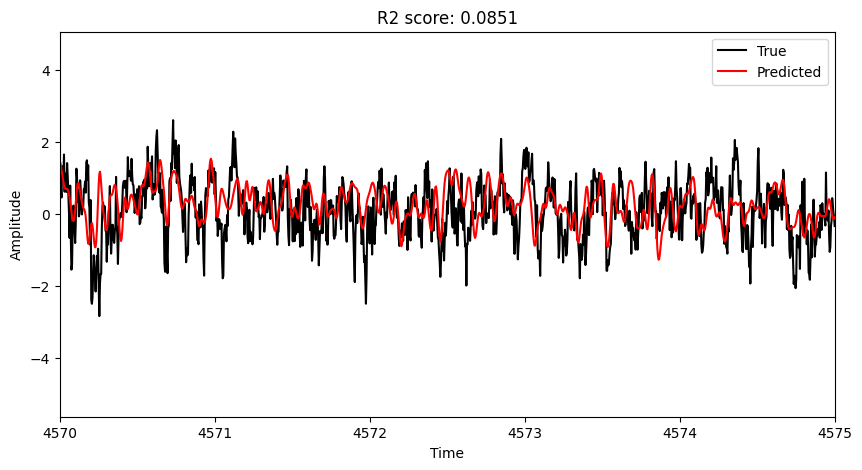

In [14]:
# 3. Evaluate the linear model
test_spikes = torch.cat([X for X, _ in test_dataloader], dim=0)
test_lfp = torch.cat([y for _, y in test_dataloader], dim=0)

# reshape to time X features
test_spikes = test_spikes.reshape(test_spikes.shape[0] * test_spikes.shape[1], test_spikes.shape[2])
test_lfp = test_lfp.reshape(test_lfp.shape[0] * test_lfp.shape[1])
 
y_hat_test = linear_model.evaluate(test_spikes)

time_test = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time_test, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time_test, y_hat_test, 'r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test):.4f}')
ax.legend()

y_hat_spont = linear_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float())

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont, 'r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont):.4f}')
ax.legend()


In [75]:
# LSTM model
import importlib
importlib.reload(models)

criterion = torch.nn.MSELoss()
num_epochs = 15
lstm_model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength), criterion, device)
lstm_train_loss, lstm_test_loss = lstm_model.train(train_dataloader,
                                        test_dataloader , num_epochs)

print(f'LSTM  train loss: {lstm_train_loss[-1]:.4f}')
print(f'LSTM  test loss: {lstm_test_loss[-1]:.4f}')

LSTM  train loss: 0.2316
LSTM  test loss: 0.3169


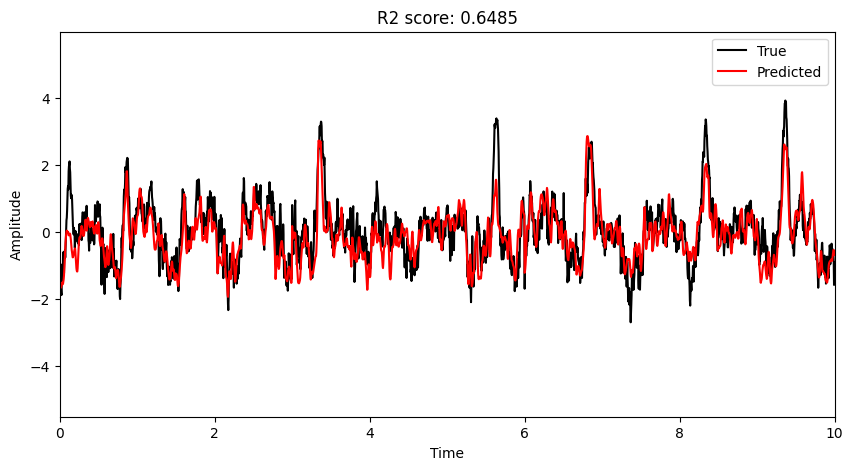

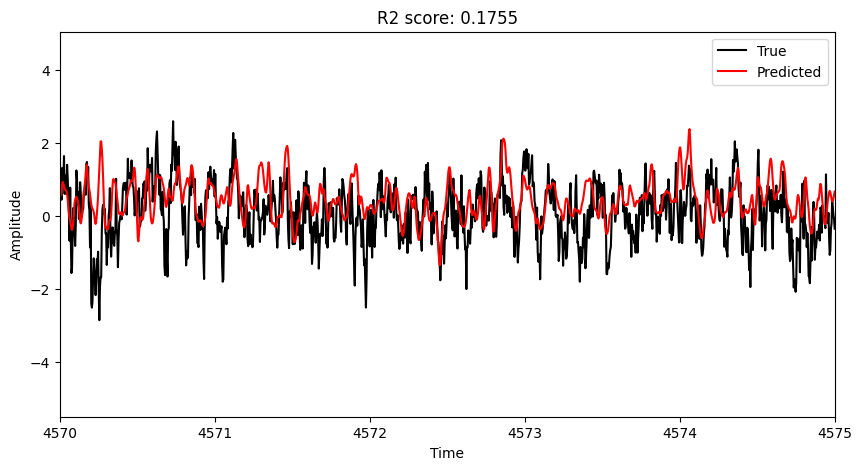

In [77]:
y_hat_test = lstm_model.evaluate(test_spikes)

time = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test, 'r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test):.4f}')
ax.legend()
plt.show()
y_hat_spont = lstm_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float().to(device))

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont, 'r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont):.4f}')
ax.legend()
plt.show()

In [47]:
# transformer model
import importlib
importlib.reload(models)

num_epochs = 10
transformer_model = models.process_model(models.SpikingTransformer(input_size=input_size, seqlength=seqlength,
                                                                   embedding_dim = 64, num_heads = 8, 
                                                                   dropout=0.05), criterion, device)

transformer_train_loss, transformer_test_loss = transformer_model.train(train_dataloader,
                                        test_dataloader , num_epochs)

print(f'transformer  train loss: {transformer_train_loss[-1]:.4f}')
print(f'transformer  test loss:  {transformer_test_loss[-1]:.4f}')

transformer  train loss: 0.3231
transformer  test loss:  0.3160


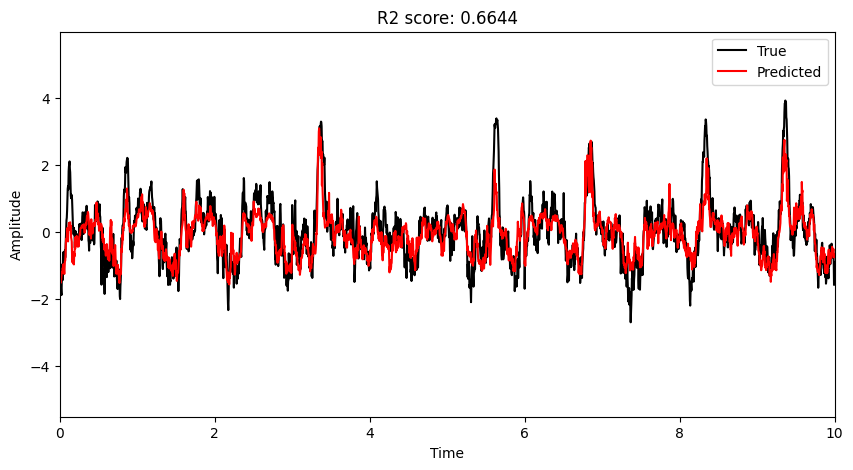

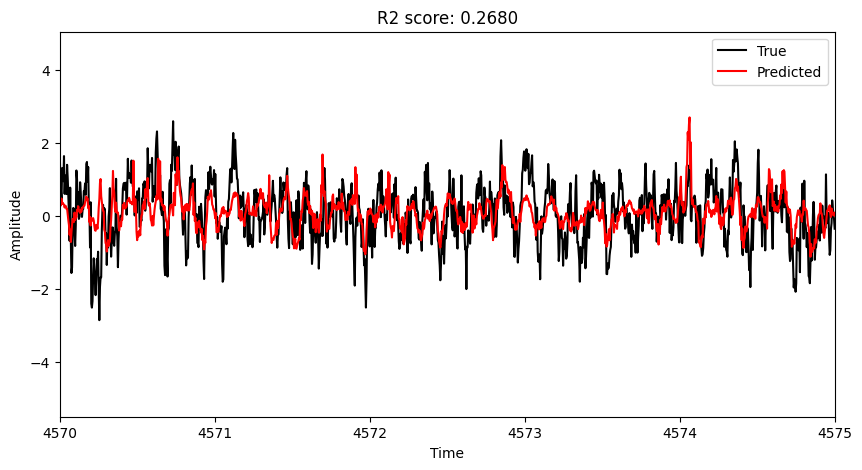

In [ ]:
y_hat_test = transformer_model.evaluate(test_spikes)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test, 'r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test):.4f}')
ax.legend()
plt.show()

y_hat_spont = transformer_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float())

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont, 'r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont):.4f}')
ax.legend()
plt.show()